# Волновое поле в суперзеркале Ni/Ti

Исправлены знак поглощения, передача толщин слоёв, точность входных данных,
диагностика потоков и расчётные/графические ячейки.

- Аргумент функций `q` сохранён для совместимости и означает **$k_\perp$**, а не $Q=2k_\perp$.
- Прямая волна: $e^{ik_j z}$; комплексная SLD: $\rho'_j-i\rho''_j$, $\rho''_j\ge0$.
- $k_j^2=k_\perp^2-4\pi\rho'_j+i4\pi\rho''_j$.
- Все толщины Ni/Ti читаются из `profile_data_GRB.npy` в нм и переводятся в Å.
- Подложка Si остаётся полубесконечной: `[0, 2.074, 0]`.
- Значения поглощения Ni/Ti сохранены: 0.001 в единицах $10^{-6}$ Å$^{-2}$.

Поместите `.npy` рядом с ноутбуком и выполните **Restart Kernel → Run All**.
Путь при необходимости задаётся в `DATA_PATH` ниже.

Основание: [Kolevatov et al.](https://arxiv.org/abs/1708.04486), с. 5–6,
формулы (9)–(11), (15), (19), (20). Поток вычисляется непосредственно как
$J=(\hbar/m)\operatorname{Im}(\psi^*\psi')$.


In [64]:
import torch
import numpy as np
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np_pi = np.pi
from pathlib import Path


def sqrt_decay_branch(z: torch.Tensor) -> torch.Tensor:
    """
    Комплексный sqrt с выбором ветви, обеспечивающей затухание:
        Im(k) >= 0.
    Если k чисто вещественное, выбирается Re(k) >= 0.
    """
    z = torch.as_tensor(z, dtype=torch.complex128, device=z.device)

    k = torch.sqrt(z)

    # Основная проверка: затухающая ветвь
    k = torch.where(k.imag < 0.0, -k, k)

    # Не переворачиваем почти вещественный корень: это может нарушить Im(k) >= 0.
    k = torch.where((k.imag == 0) & (k.real < 0), -k, k)

    return k


def safe_div(num: torch.Tensor, den: torch.Tensor, eps: float = 1e-30) -> torch.Tensor:
    """
    Безопасное комплексное деление.
    Заменяет слишком малые знаменатели на eps.
    """
    num = torch.as_tensor(num, dtype=torch.complex128, device=den.device)
    den = torch.as_tensor(den, dtype=torch.complex128, device=den.device)

    small = torch.abs(den) < eps

    if torch.any(small):
        den = torch.where(
            small,
            torch.full_like(den, eps, dtype=torch.complex128),
            den
        )

    return num / den

 
def stable_multilayer_fields(
    q,
    layers,
    np_pi=np.pi,
    device=None,
    eps=1e-30
):
    """
    Устойчивый расчёт многослойной структуры методом scattering-рекурсии.

    Параметры
    ---------
    q : torch.Tensor или array-like
        Нормальная компонента k_perp падающей волны, Å^-1 (НЕ Q = 2*k_perp).
        Форма: (nq,)

    layers : torch.Tensor или array-like
        Массив слоёв формы (n_media, 3):
            columns: thickness [Å], Re(SLD), magnitude of absorptive SLD
            SLD задана в единицах 10^-6 Å^-2; комплексная SLD = Re - i*abs(Im).

        Ожидается:
            layers[0]      падающая среда
            layers[1:-1]   конечные слои
            layers[-1]     подложка

    np_pi : float or torch.Tensor
        Число pi; множитель 4 уже присутствует в формуле для k.

    device : str or torch.device, optional
        Устройство.

    eps : float
        Регуляризация для деления.

    Возвращает
    ----------
    r_global : Tensor, shape (nq,)
        Полная амплитуда отражения.

    k : Tensor, shape (nq, n_media)
        Волновые числа с ветвью Im(k) >= 0.

    A_left : Tensor, shape (nq, n_media)
        Амплитуда прямой волны на левой границе каждой среды.

    B_right : Tensor, shape (nq, n_media)
        Амплитуда обратной волны на правой границе каждой конечной среды.
        Для подложки B_right = 0.
        Для падающей среды сюда записана r_global для удобства.

    p : Tensor, shape (nq, n_media)
        Факторы прохождения p_j = exp(i k_j d_j).
        Для падающей среды и подложки p = 1.

    R_eff : Tensor, shape (nq, n_media)
        Эффективные отражения для конечных слоёв.
        Нужно в основном для диагностики.
    """

    if device is None:
        device = q.device if torch.is_tensor(q) else torch.device("cpu")
    else:
        device = torch.device(device)

    q = torch.as_tensor(q, dtype=torch.complex128, device=device).reshape(-1)
    layers = torch.as_tensor(layers, dtype=torch.float64, device=device)

    if layers.ndim != 2 or layers.shape[1] != 3:
        raise ValueError("layers: ожидаются столбцы [толщина, Re SLD, поглощение].")
    if not torch.all(torch.isfinite(layers)) or not torch.all(torch.isfinite(q)):
        raise ValueError("Входные данные содержат NaN или inf.")
    if torch.any(q.imag != 0) or torch.any(q.real <= 0):
        raise ValueError("k_perp должен быть действительным и положительным.")
    if layers[0, 2] != 0:
        raise ValueError("В этой модели падающая среда должна быть непоглощающей.")
    if torch.any(layers[1:-1, 0] <= 0):
        raise ValueError("Толщины конечных слоёв должны быть положительными.")
    n_media = layers.shape[0]

    if n_media < 2:
        raise ValueError("layers должен содержать хотя бы падающую среду и подложку.")

    n_fin = n_media - 2
    nq = q.shape[0]

    # ------------------------------------------------------------------
    # 1. Пассивная среда при прямой волне exp(+i*k*z):
    #    sld[0] = 0
    #    sld[1:] = (Re_layers - Re_incident) - i |Im_layers|, умноженное на 1e-6
    # ------------------------------------------------------------------
    sld = torch.zeros(n_media, dtype=torch.complex128, device=device)

    if n_media > 1:
        sld[1:] = (
            (layers[1:, 1] - layers[0, 1])
            - 1j * torch.abs(layers[1:, 2])
        ) * 1.0e-6

    # ------------------------------------------------------------------
    # 2. Волновые числа с правильной ветвью затухания
    # ------------------------------------------------------------------
    const = torch.as_tensor(np_pi, dtype=torch.float64, device=device)

    arg = q[:, None] ** 2.0 - 4.0 * const * sld[None, :]

    k = sqrt_decay_branch(arg)

    # ------------------------------------------------------------------
    # 3. Интерфейсные коэффициенты
    #    r_if[:, j]  : отражение на границе j -> j+1 при падении слева
    #    r_back[:, j]: отражение при падении справа
    #    t_if[:, j]  : прохождение слева направо
    #    t_back[:, j]: прохождение справа налево
    # ------------------------------------------------------------------
    k_left = k[:, :-1]
    k_right = k[:, 1:]

    den_if = k_left + k_right

    r_if = safe_div(k_left - k_right, den_if, eps=eps)
    r_back = -r_if

    t_if = safe_div(2.0 * k_left, den_if, eps=eps)
    t_back = safe_div(2.0 * k_right, den_if, eps=eps)

    # ------------------------------------------------------------------
    # 4. Факторы прохождения через слои
    #    p_j = exp(i k_j d_j)
    #
    #    При Im(k_j) >= 0 выполняется |p_j| <= 1.
    #    Это исключает растущие множители; пассивность проверяется также по потоку.
    # ------------------------------------------------------------------
    p = torch.ones_like(k)

    if n_fin > 0:
        d = layers[1:n_media - 1, 0].to(dtype=torch.float64, device=device)
        p[:, 1:n_media - 1] = torch.exp(
            1j * k[:, 1:n_media - 1] * d[None, :]
        )

    # ------------------------------------------------------------------
    # 5. Обратный проход: эффективные отражения R_j
    #
    #    R_j определяется на правой границе слоя j и включает все слои правее.
    #    Для последнего конечного слоя:
    #        R_last = r_last, interface last -> substrate
    # ------------------------------------------------------------------
    R_eff = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)

    A_left = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)
    B_right = torch.zeros(nq, n_media, dtype=torch.complex128, device=device)

    # Случай без конечных слоёв: только граница среда -> подложка
    if n_fin == 0:
        r_global = r_if[:, 0].clone()

        A_left[:, 0] = 1.0
        B_right[:, 0] = r_global

        A_left[:, 1] = t_if[:, 0]
        B_right[:, 1] = 0.0

        return r_global, k, A_left, B_right, p, R_eff

    last_fin = n_fin  # индекс последнего конечного слоя, равный n_media - 2

    # Граница последний конечный слой -> подложка
    R_eff[:, last_fin] = r_if[:, last_fin]

    # Движемся справа налево по конечным слоям
    for j in range(last_fin - 1, 0, -1):
        # Эффективное отражение следующего слоя, приведённое к левой границе слоя j+1
        rho_next = p[:, j + 1] ** 2 * R_eff[:, j + 1]

        den_s = 1.0 - r_back[:, j] * rho_next

        R_eff[:, j] = (
            r_if[:, j]
            + safe_div(t_if[:, j] * t_back[:, j] * rho_next, den_s, eps=eps)
        )

    # ------------------------------------------------------------------
    # 6. Полное отражение от всей структуры
    # ------------------------------------------------------------------
    rho_1 = p[:, 1] ** 2 * R_eff[:, 1]

    den_0 = 1.0 - r_back[:, 0] * rho_1

    r_global = (
        r_if[:, 0]
        + safe_div(t_if[:, 0] * t_back[:, 0] * rho_1, den_0, eps=eps)
    )

    # ------------------------------------------------------------------
    # 7. Прямой проход: амплитуды внутри слоёв
    #
    #    A_left[j]  : амплитуда прямой волны на левой границе слоя j
    #    B_right[j] : амплитуда обратной волны на правой границе слоя j
    # ------------------------------------------------------------------
    A_left[:, 0] = 1.0
    B_right[:, 0] = r_global  # удобно для расчёта поля в падающей среде

    A_left[:, 1] = safe_div(t_if[:, 0], den_0, eps=eps)
    B_right[:, 1] = p[:, 1] * R_eff[:, 1] * A_left[:, 1]

    for j in range(1, last_fin):
        # Прямая волна на правой границе слоя j
        F_j = A_left[:, j] * p[:, j]

        # Нагрузка со стороны слоя j+1, приведённая к интерфейсу j
        rho_next = p[:, j + 1] ** 2 * R_eff[:, j + 1]

        den = 1.0 - r_back[:, j] * rho_next

        A_left[:, j + 1] = safe_div(t_if[:, j] * F_j, den, eps=eps)

        B_right[:, j + 1] = p[:, j + 1] * R_eff[:, j + 1] * A_left[:, j + 1]

    # Подложка: только прямая волна, обратной волны нет
    F_last = A_left[:, last_fin] * p[:, last_fin]

    A_left[:, n_media - 1] = t_if[:, last_fin] * F_last
    B_right[:, n_media - 1] = 0.0

    return r_global, k, A_left, B_right, p, R_eff

def evaluate_psi_squared_stable(
    A_left,
    B_right,
    k,
    layers,
    z,
    z0=0.0,
    eps=1e-30
):
    """
    Устойчивый расчёт |psi(z)|^2 для многослойной структуры.

    Параметры
    ---------
    A_left : Tensor, shape (nq, n_media)
        Амплитуды прямых волн на левых границах сред.

    B_right : Tensor, shape (nq, n_media)
        Амплитуды обратных волн на правых границах сред.
        B_right[:, 0] должен содержать r_global.

    k : Tensor, shape (nq, n_media)
        Волновые числа.

    layers : Tensor, shape (n_media, 3)
        Массив слоёв: thickness, Re(SLD), Im(SLD).

    z : Tensor or array-like, shape (nz,)
        Точки, в которых вычисляется волновая функция.

    z0 : float or Tensor
        Координата передней поверхности.
        По умолчанию 0.

    eps : float
        Не используется напрямую, оставлено для совместимости стиля.

    Возвращает
    ----------
    psi_squared : Tensor, shape (nq, nz)
        |psi(q_i, z_j)|^2.
    """

    device = A_left.device

    z = torch.as_tensor(z, dtype=torch.float64, device=device).reshape(-1)
    layers = torch.as_tensor(layers, dtype=torch.float64, device=device)

    nq, n_media = A_left.shape
    nz = z.shape[0]

    psi_squared = torch.zeros(nq, nz, dtype=torch.float64, device=device)
    filled = torch.zeros(nz, dtype=torch.bool, device=device)

    n_fin = n_media - 2

    z0 = torch.as_tensor(z0, dtype=torch.float64, device=device).reshape(())

    # ------------------------------------------------------------------
    # Границы конечных слоёв:
    #
    # bounds[0] = z0
    # bounds[1] = z0 + d_1
    # bounds[2] = z0 + d_1 + d_2
    # ...
    # bounds[n_fin] = конец последнего конечного слоя
    # ------------------------------------------------------------------
    if n_fin > 0:
        d = layers[1:n_media - 1, 0].to(dtype=torch.float64, device=device)

        bounds = torch.empty(n_fin + 1, dtype=torch.float64, device=device)
        bounds[0] = z0
        bounds[1:] = z0 + torch.cumsum(d, dim=0)

        z_end = bounds[-1]
    else:
        bounds = torch.tensor([z0, z0], dtype=torch.float64, device=device)
        z_end = z0

    # ------------------------------------------------------------------
    # Падающая среда: z < z0
    #
    # psi_0(z) = exp(i k_0 (z - z0)) + r_global exp(-i k_0 (z - z0))
    # ------------------------------------------------------------------
    mask_incident = (z < bounds[0]) & (~filled)

    if torch.any(mask_incident):
        zz = z[mask_incident]
        x = zz - bounds[0]

        k0 = k[:, 0].unsqueeze(1)
        r0 = B_right[:, 0].unsqueeze(1)

        psi = (
            torch.exp(1j * k0 * x[None, :])
            + r0 * torch.exp(-1j * k0 * x[None, :])
        )

        psi_squared[:, mask_incident] = torch.abs(psi) ** 2
        filled[mask_incident] = True

    # ------------------------------------------------------------------
    # Конечные слои: j = 1 ... n_media - 2
    #
    # psi_j(z) =
    #   A_left[j]  exp(i k_j (z - z_left))
    # + B_right[j] exp(i k_j (z_right - z))
    # ------------------------------------------------------------------
    for j in range(1, n_media - 1):
        z_left = bounds[j - 1]
        z_right = bounds[j]

        # Чтобы не дублировать границы, последний конечный слой берём включительно
        if j == n_media - 2:
            mask = (z >= z_left) & (z <= z_right) & (~filled)
        else:
            mask = (z >= z_left) & (z < z_right) & (~filled)

        if not torch.any(mask):
            continue

        zz = z[mask]

        x = zz - z_left
        d_layer = z_right - z_left

        A = A_left[:, j].unsqueeze(1)
        B = B_right[:, j].unsqueeze(1)
        kj = k[:, j].unsqueeze(1)

        psi = (
            A * torch.exp(1j * kj * x[None, :])
            + B * torch.exp(1j * kj * (d_layer - x)[None, :])
        )

        psi_squared[:, mask] = torch.abs(psi) ** 2
        filled[mask] = True

    # ------------------------------------------------------------------
    # Подложка: z > z_end
    #
    # psi_sub(z) = A_left[-1] exp(i k_sub (z - z_end))
    # Обратной волны в подложке нет.
    # ------------------------------------------------------------------
    mask_substrate = (z >= z_end) & (~filled)

    if torch.any(mask_substrate):
        zz = z[mask_substrate]
        x = zz - z_end

        A_sub = A_left[:, -1].unsqueeze(1)
        k_sub = k[:, -1].unsqueeze(1)

        psi = A_sub * torch.exp(1j * k_sub * x[None, :])

        psi_squared[:, mask_substrate] = torch.abs(psi) ** 2
        filled[mask_substrate] = True

    if not torch.all(filled):
        raise ValueError("Не все координаты z попали в области модели; проверьте z и границы.")

    return psi_squared





def reflec_new_stable(
    q,
    layers,
    bkg,
    scale,
    np_pi=np.pi,
    device=None,
    eps=1e-30
):
    """
    Совместимая по смыслу замена reflec_new, но с устойчивым расчётом.

    Возвращает:
        r, D_q_alpha, kn, reflectivity, T_flux

    r : полная амплитуда отражения
    D_q_alpha : legacy-массив, если он нужен старому коду
    kn : волновые числа
    reflectivity : |r|^2 с Вашими множителем и фоном
    T_flux : коэффициент прохождения по потоку (без фона и масштаба)
    """

    r, kn, A_left, B_right, p, R_eff = stable_multilayer_fields(
        q=q,
        layers=layers,
        np_pi=np_pi,
        device=device,
        eps=eps
    )

    reflectivity = torch.abs(r) ** 2

    # Экспериментальные фон и масштаб не входят в физический баланс потоков.
    scale = torch.as_tensor(scale, dtype=torch.float64, device=kn.device)
    bkg = torch.as_tensor(bkg, dtype=torch.float64, device=kn.device)
    reflectivity = (
        reflectivity * torch.pow(10.0, scale)
        + torch.pow(10.0, bkg)
    )

    # Legacy D_q_alpha, если где-то ещё используется старый код
    nq, n_media = kn.shape

    D_q_alpha = torch.zeros(
        nq, n_media, 2, 2,
        dtype=torch.complex128,
        device=kn.device
    )

    D_q_alpha[:, :, 0, 0] = 1.0
    D_q_alpha[:, :, 0, 1] = 1.0
    D_q_alpha[:, :, 1, 0] = kn
    D_q_alpha[:, :, 1, 1] = -kn

    # Поток на входе в подложку. Для непоглощающей падающей среды это точная формула.
    T_flux = kn[:, -1].real / kn[:, 0].real * torch.abs(A_left[:, -1]) ** 2

    return r, D_q_alpha, kn, torch.real(reflectivity), T_flux


In [65]:
DATA_PATH = Path("profile_data_GRB.npy")
# Дополнительный относительный путь к приложению в рабочем проекте.
if not DATA_PATH.is_file():
    candidates = [Path("project_sources/06-profile_data_GRB.npy"),
                  Path("../project_sources/06-profile_data_GRB.npy")]
    DATA_PATH = next((p for p in candidates if p.is_file()), DATA_PATH)
if not DATA_PATH.is_file():
    raise FileNotFoundError("Укажите путь к profile_data_GRB.npy в DATA_PATH.")

dataset = np.load(DATA_PATH, allow_pickle=False)
if dataset.ndim != 2 or dataset.shape[1] != 3 or len(dataset) == 0:
    raise ValueError("Ожидается массив (N, 3): номер пары, d_Ni [нм], d_Ti [нм].")
if not np.isfinite(dataset).all() or np.any(dataset[:, 1:3] <= 0):
    raise ValueError("Толщины должны быть конечными положительными числами.")

n_pairs = len(dataset)
# Порядок от поверхности: Ni_1, Ti_1, Ni_2, Ti_2, ..., Si.
finite_thicknesses = torch.as_tensor(
    dataset[:, 1:3].reshape(-1) * 10.0, dtype=torch.float64, device=device
)
layers_test = torch.zeros((2 * n_pairs + 2, 3), dtype=torch.float64, device=device)
layers_test[1:-1, 0] = finite_thicknesses

# Be
layers_test[1:-1:2, 1] = 9.620
layers_test[1:-1:2, 2] = 0.0001

# Ti
layers_test[2:-1:2, 1] = -1.925
layers_test[2:-1:2, 2] = 0.001

# Подложка Si
layers_test[-1, 1] = 2.074
# Координаты интерфейсов используются только как координаты, не как толщины.
interfaces = torch.cat((torch.zeros(1, dtype=torch.float64, device=device),
                        torch.cumsum(finite_thicknesses, dim=0)))
total_thickness = interfaces[-1].item()
print(f"Пар Ni/Ti: {n_pairs}; конечных слоёв: {2*n_pairs}")
print(f"Первый Ni: {finite_thicknesses[0].item():.6f} Å")
print(f"Толщина покрытия: {total_thickness:.6f} Å ({total_thickness/1e4:.6f} мкм)")


Пар Ni/Ti: 274; конечных слоёв: 548
Первый Ni: 1220.861003 Å
Толщина покрытия: 38204.687420 Å (3.820469 мкм)


In [66]:

def integrate_layers_analytic(A_left, B_right, k, layers):
    """Точные интегралы |psi|² по конечным слоям, Tensor (n_layers, n_k), Å.

    A_left и B_right отсчитываются от разных границ слоя.
    Для каждого слоя psi(x)=A*exp(ikx)+B*exp(ik(d-x)).
    Координатная сетка и psi2_test не требуются.
    """
    layers = torch.as_tensor(layers, dtype=torch.float64, device=k.device)
    if A_left.shape != k.shape or B_right.shape != k.shape:
        raise ValueError("A_left, B_right и k должны иметь одинаковую форму (n_k, n_media).")
    if layers.shape != (k.shape[1], 3):
        raise ValueError("layers должен иметь форму (n_media, 3).")
    kj = k[:, 1:-1]
    d = layers[None, 1:-1, 0]
    A, B = A_left[:, 1:-1], B_right[:, 1:-1]
    beta = kj.imag
    # При beta=0 первый множитель равен d; деления 0/0 нет.
    den = torch.where(beta != 0, 2 * beta, torch.ones_like(beta))
    attenuation_integral = torch.where(beta != 0, -torch.expm1(-2 * beta * d) / den, d)
    integral_psi2 = (
        (torch.abs(A)**2 + torch.abs(B)**2) * attenuation_integral
        + 2 * (A * B.conj()).real * torch.exp(-beta * d)
        * d * torch.sinc(kj.real * d / torch.pi)
    )
    return integral_psi2.transpose(0, 1)


def flux_balance_diagnostics(q, r, k, A_left, B_right, p, layers, label=""):
    """R, T, потери через токи и независимый интеграл |psi|².

    Токи нормированы на падающий ток; потери учитываются в конечных слоях.
    T — поток на входе в подложку. Никакого обрезания R/T/L к [0, 1] нет.
    """
    k_inc = k[:, 0].real
    R = torch.abs(r) ** 2
    T = k[:, -1].real / k_inc * torch.abs(A_left[:, -1]) ** 2

    # Значения psi и dpsi/dz на левой и правой границах каждой среды.
    psi_left = A_left + B_right * p
    dpsi_left = 1j * k * (A_left - B_right * p)
    psi_right = A_left * p + B_right
    dpsi_right = 1j * k * (A_left * p - B_right)
    J_left = (psi_left.conj() * dpsi_left).imag / k_inc[:, None]
    J_right = (psi_right.conj() * dpsi_right).imag / k_inc[:, None]
    L_layers = J_left[:, 1:-1] - J_right[:, 1:-1]
    L_current = L_layers.sum(dim=1)

    # Точный интеграл общий с расчётом послойного поглощения ниже.
    integral_psi2 = integrate_layers_analytic(A_left, B_right, k, layers).transpose(0, 1)
    L_integral_layers = 4 * torch.pi * layers[None, 1:-1, 2].abs() * 1e-6 * integral_psi2 / k_inc[:, None]
    L_integral = L_integral_layers.sum(dim=1)
    residual = R + T + L_integral - 1
    idx = int(torch.argmax(residual.abs()).item())
    errors = {
        "R+T+L_integral-1": residual.abs().max().item(),
        "R+T+L_current-1": (R + T + L_current - 1).abs().max().item(),
        "L_current-L_integral": (L_current - L_integral).abs().max().item(),
        "L_layer_current-L_layer_integral": (L_layers - L_integral_layers).abs().max().item() if L_layers.numel() else 0.0,
        "jump_psi": (psi_right[:, :-1] - psi_left[:, 1:]).abs().max().item(),
        "jump_dpsi": (dpsi_right[:, :-1] - dpsi_left[:, 1:]).abs().max().item(),
        "jump_normalized_current": (J_right[:, :-1] - J_left[:, 1:]).abs().max().item(),
    }
    print(f"\n{label}")
    print(f"max R = {R.max().item():.10g}; max T = {T.max().item():.10g}")
    print(f"R+T: {(R+T).min().item():.10g} ... {(R+T).max().item():.10g}")
    print(f"L: {L_integral.min().item():.10g} ... {L_integral.max().item():.10g}")
    for name, value in errors.items():
        print(f"max |{name}| = {value:.3e}")
    print(f"Худшая точка полного баланса: k_perp = {q[idx].item():.10g} Å^-1")
    if R.max() > 1 + 1e-8 or T.max() > 1 + 1e-8 or L_integral.min() < -1e-8:
        raise RuntimeError("Нарушена пассивность: проверьте знаки SLD и потоков.")
    if not torch.all(torch.isfinite(residual)) or errors["R+T+L_integral-1"] > 1e-8:
        raise RuntimeError("Полный баланс потоков не прошёл проверку.")
    return dict(R=R, T=T, L=L_integral, L_current=L_current,
                L_layers=L_layers, residual=residual, errors=errors)


In [67]:
# q_test сохраняет прежний смысл k_perp. Деления на 2 здесь нет.
q_test = torch.linspace(0.001, 0.05, 5000, dtype=torch.float64, device=device)
r_test, k_test, A_test, B_test, p_test, R_test = stable_multilayer_fields(
    q_test, layers_test, np_pi=np_pi, device=device
)
diagnostics = flux_balance_diagnostics(
    q_test, r_test, k_test, A_test, B_test, p_test, layers_test,
    label="Суперзеркало с поглощением"
)
R, T, L = diagnostics["R"], diagnostics["T"], diagnostics["L"]
print("min Re(k):", k_test.real.min().item())
print("min Im(k):", k_test.imag.min().item())
print("max |p|:", p_test.abs().max().item())

# Отдельная копия для контрольного расчёта: основная структура сохраняется.
def check_lossless_structure(q, layers):
    lossless_layers = layers.clone()
    lossless_layers[:, 2] = 0.0
    r0, k0, A0, B0, p0, _ = stable_multilayer_fields(q, lossless_layers, device=q.device)
    diag = flux_balance_diagnostics(q, r0, k0, A0, B0, p0, lossless_layers,
                                    label="Та же структура без поглощения")
    error = (diag["R"] + diag["T"] - 1).abs().max().item()
    print(f"max |R+T-1| без поглощения = {error:.3e}")
    return error

lossless_balance_error = check_lossless_structure(q_test, layers_test)



Суперзеркало с поглощением
max R = 0.9999981013; max T = 0.9950533193
R+T: 0.9760191467 ... 0.9999981013
L: 1.898741203e-06 ... 0.02398085328
max |R+T+L_integral-1| = 7.131e-13
max |R+T+L_current-1| = 6.986e-13
max |L_current-L_integral| = 2.320e-14
max |L_layer_current-L_layer_integral| = 4.089e-15
max |jump_psi| = 1.738e-15
max |jump_dpsi| = 5.594e-17
max |jump_normalized_current| = 7.447e-15
Худшая точка полного баланса: k_perp = 0.03261132226 Å^-1
min Re(k): 0.0
min Im(k): 0.0
max |p|: 1.0

Та же структура без поглощения
max R = 1; max T = 0.9999851344
R+T: 1 ... 1
L: 0 ... 0
max |R+T+L_integral-1| = 6.118e-13
max |R+T+L_current-1| = 6.127e-13
max |L_current-L_integral| = 1.990e-14
max |L_layer_current-L_layer_integral| = 3.115e-15
max |jump_psi| = 1.790e-15
max |jump_dpsi| = 4.655e-17
max |jump_normalized_current| = 6.634e-15
Худшая точка полного баланса: k_perp = 0.03147429486 Å^-1
max |R+T-1| без поглощения = 6.118e-13


Карта |psi|²: (1000, 4000); максимум на сетке: 76.5992


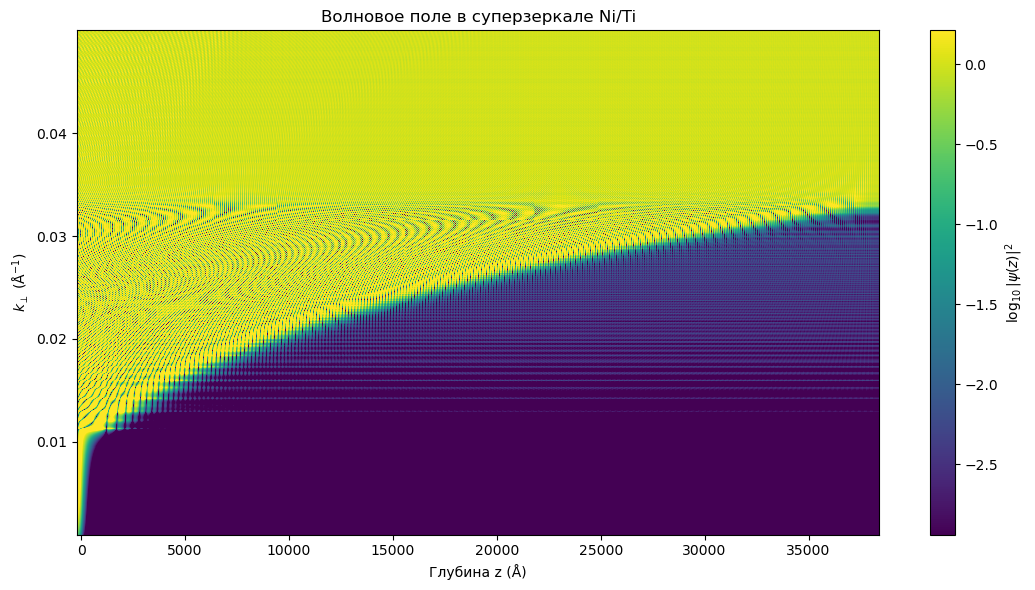

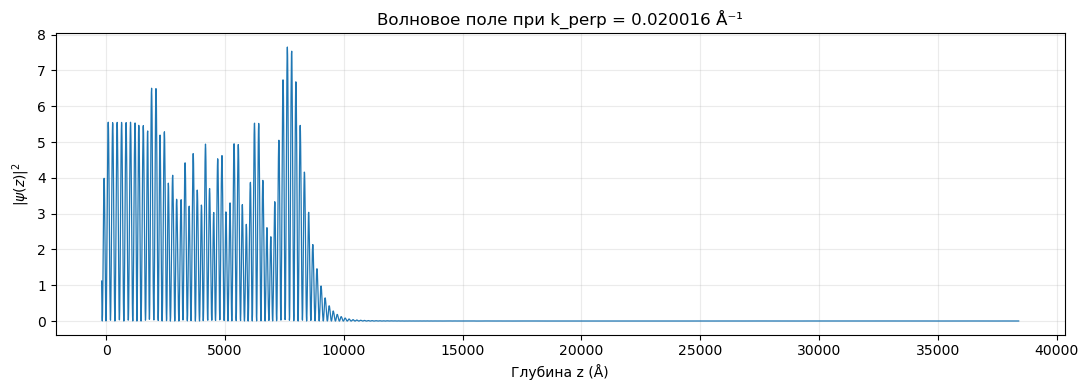

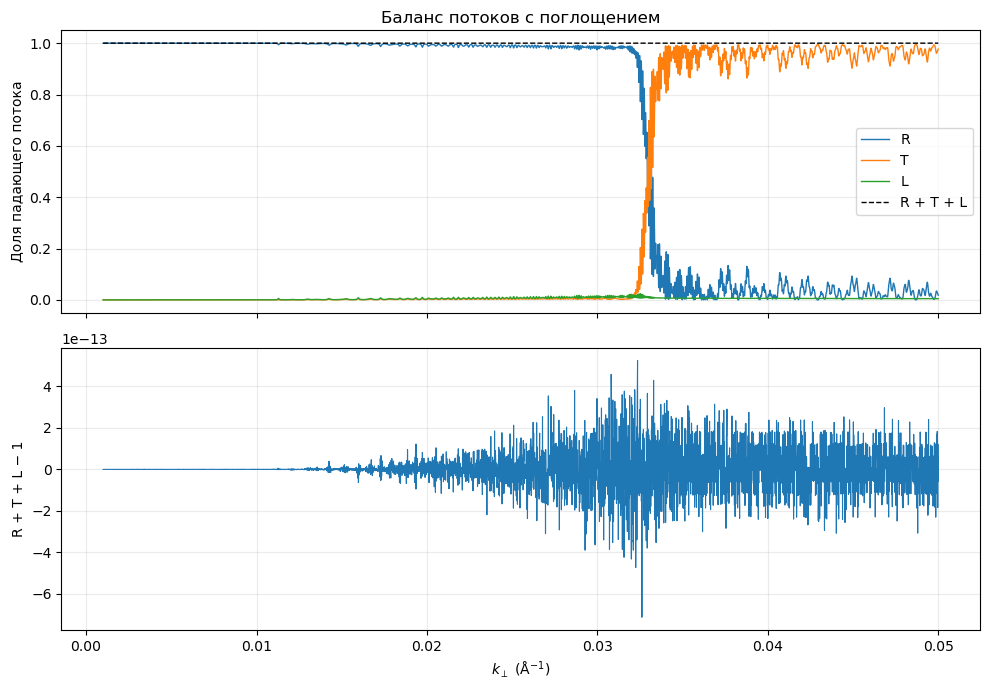

In [68]:
def to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

def plot_psi_squared_heatmap(psi_squared, q_values, z_values,
                             title="Волновое поле в суперзеркале Ni/Ti"):
    fig, ax = plt.subplots(figsize=(11, 6))
    values = np.log10(np.maximum(to_numpy(psi_squared), 1e-30))
    im = ax.pcolormesh(to_numpy(z_values), to_numpy(q_values), values,
                       shading="auto", cmap="viridis",vmin=np.percentile(values, 30), vmax=np.percentile(values, 90) )
    fig.colorbar(im, ax=ax, label=r"$\log_{10}|\psi(z)|^2$")
    ax.set(xlabel="Глубина z (Å)", ylabel=r"$k_\perp$ (Å$^{-1}$)", title=title)
    fig.tight_layout()
    plt.show()

def plot_psi_squared_1d(psi_squared, z_values, q_values, q_index, title=None):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(to_numpy(z_values), to_numpy(psi_squared[q_index]), lw=0.9)
    if title is None:
        title = f"Волновое поле при k_perp = {to_numpy(q_values)[q_index]:.6f} Å⁻¹"
    ax.set(xlabel="Глубина z (Å)", ylabel=r"$|\psi(z)|^2$", title=title)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

# Баланс проверен на всех 5000 k_perp. Карта имеет отдельную настраиваемую сетку.
K_PLOT_STRIDE = 5
N_Z = 4000
plot_indices = torch.arange(0, len(q_test), K_PLOT_STRIDE, device=device)
q_plot = q_test[plot_indices]
z_test = torch.linspace(-200.0, total_thickness + 200.0, N_Z,
                        dtype=torch.float64, device=device)
psi2_test = evaluate_psi_squared_stable(
    A_test[plot_indices], B_test[plot_indices], k_test[plot_indices], layers_test, z_test
)
print(f"Карта |psi|²: {tuple(psi2_test.shape)}; максимум на сетке: {psi2_test.max().item():.6g}")
plot_psi_squared_heatmap(psi2_test, q_plot, z_test)
q_index = int(torch.argmin(torch.abs(q_plot - 0.02)).item())
plot_psi_squared_1d(psi2_test, z_test, q_plot, q_index)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
k_np = to_numpy(q_test)
for values, label in [(R, "R"), (T, "T"), (L, "L")]:
    axes[0].plot(k_np, to_numpy(values), lw=1, label=label)
axes[0].plot(k_np, to_numpy(R + T + L), "k--", lw=1, label="R + T + L")
axes[0].set(ylabel="Доля падающего потока", title="Баланс потоков с поглощением")
axes[0].legend()
axes[1].plot(k_np, to_numpy(diagnostics["residual"]), lw=0.8)
axes[1].set(xlabel=r"$k_\perp$ (Å$^{-1}$)", ylabel="R + T + L − 1")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Примечания и документация

- `reflec_new_stable` сохраняет пять выходов, но пятый теперь означает **T по потоку**, а не $|A_\mathrm{sub}|^2$.
  Возвращаемое отражение с фоном/масштабом не используется при проверке физического баланса.
- Значения поглощения 0.001 оставлены из исходного файла; они не заменяют отдельный подбор физических констант Ni и Ti.
- `q_index` в графике относится к `q_plot`. Сетка графика не меняет расчёт R, T и потерь.
- В точном критическом значении $k_j=0$ базис двух экспонент вырождается;
  `eps` в делении не является аналитическим пределом. Проверки выше относятся к заданной сетке.

Документация используемых библиотек:
[PyTorch: точность вычислений](https://docs.pytorch.org/docs/2.14/notes/numerical_accuracy.html),
[типы по умолчанию](https://docs.pytorch.org/docs/2.14/generated/torch.set_default_dtype.html),
[torch.expm1](https://docs.pytorch.org/docs/2.14/generated/torch.expm1.html),
[torch.sinc](https://docs.pytorch.org/docs/2.14/generated/torch.sinc.html),
[NumPy: загрузка .npy](https://numpy.org/doc/stable/reference/generated/numpy.load.html),
[Matplotlib: pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html),
[Python: pathlib](https://docs.python.org/3/library/pathlib.html).


## Поглощение по слоям

При единичной амплитуде падающей волны:

$$P_j(k_\perp)=\frac{4\pi\rho''_{a,j}}{k_\perp}\int_{z_j}^{z_{j+1}}|\psi(z)|^2\,dz.$$

В коде `im_sld` хранит положительную величину в единицах $10^{-6}$ Å$^{-2}$,
поэтому множитель равен `4*pi*1e-6*im_sld/k_perp`.
**В знаменателе стоит падающий k_perp, одинаковый для всех слоёв**, а не модуль комплексного k_j.
Поглощение — безразмерная доля падающего потока; проценты равны `100*P_j`.

Здесь значения `layers_test[1:-1, 2]` трактуются как поглощательная SLD.
Если они включают также диффузное рассеяние, вычисленная величина означает суммарные потери.
Для отделения истинного поглощения потребуется отдельная `im_sld_abs` (поглощательная часть),
а поле должно по-прежнему рассчитываться с полной мнимой SLD.
При `im_sld_abs < layers_test[1:-1, 2]` проверяется баланс с добавлением остальных потерь.
Основание: [Kolevatov et al.](https://arxiv.org/abs/1708.04486), формулы (9), (15), (20), (21).

Основной вариант использует точный аналитический интеграл. Метод трапеций по
`psi2_test` оставлен для сравнения; он использует **q_plot**, поскольку эта карта
рассчитана на прореженной сетке. Воздух и полубесконечная подложка в массив поглощения покрытия не входят.


In [69]:

def _real_numpy(value, name):
    a = value.detach().cpu().numpy() if torch.is_tensor(value) else np.asarray(value)
    if np.iscomplexobj(a):
        if np.any(a.imag != 0):
            raise ValueError(f"{name}: ожидаются действительные значения.")
        a = a.real
    a = np.asarray(a, dtype=np.float64)
    if not np.all(np.isfinite(a)):
        raise ValueError(f"{name}: есть NaN или inf.")
    return a


def integrate_layers(psi_squared, z, interfaces):
    """Трапеции по сетке: вход (n_k, n_z), выход (n_layers, n_k), Å.

    interfaces — координаты границ конечных слоёв, НЕ толщины.
    Поле на обеих границах каждого слоя добавляется линейной интерполяцией.
    Это устраняет пропуск краевых участков, но не погрешность грубой сетки.
    """
    psi = _real_numpy(psi_squared, "psi_squared")
    z = _real_numpy(z, "z")
    bounds = _real_numpy(interfaces, "interfaces")
    if z.ndim != 1 or len(z) < 2 or np.any(np.diff(z) <= 0):
        raise ValueError("z должен быть строго возрастающим одномерным массивом.")
    if bounds.ndim != 1 or len(bounds) < 2 or np.any(np.diff(bounds) <= 0):
        raise ValueError("interfaces должен содержать возрастающие координаты границ.")
    if psi.ndim != 2 or psi.shape[1] != len(z):
        raise ValueError("psi_squared должен иметь форму (n_k, len(z)).")
    if bounds[0] < z[0] or bounds[-1] > z[-1]:
        raise ValueError("Сетка z должна покрывать все конечные слои.")

    # Интерполируем все границы одновременно по оси z, для каждого k_perp.
    right = np.searchsorted(z, bounds, side="right")
    right = np.clip(right, 1, len(z) - 1)
    left = right - 1
    weight = (bounds - z[left]) / (z[right] - z[left])
    psi_bounds = psi[:, left] * (1 - weight) + psi[:, right] * weight
    integrals = np.empty((len(bounds) - 1, psi.shape[0]), dtype=np.float64)
    # NumPy >=2.0: trapezoid; совместимость с NumPy 1.x: trapz.
    trapezoid = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    for j, (z_min, z_max) in enumerate(zip(bounds[:-1], bounds[1:])):
        inner = (z > z_min) & (z < z_max)
        z_segment = np.concatenate(([z_min], z[inner], [z_max]))
        psi_segment = np.concatenate((psi_bounds[:, j:j+1], psi[:, inner],
                                      psi_bounds[:, j+1:j+2]), axis=1)
        integrals[j] = trapezoid(psi_segment, x=z_segment, axis=1)
    return integrals


def compute_absorption(integrals_layers, im_sld, wave_vector):
    """Поглощение / падающий поток: ndarray (n_layers, n_k).

    integrals_layers: интегралы |psi|² в Å, форма (n_layers, n_k).
    im_sld: положительная поглощательная SLD в 10^-6 Å^-2, форма (n_layers,).
    wave_vector: падающий k_perp в Å^-1, форма (n_k,), НЕ массив k_j.
    """
    integrals = _real_numpy(integrals_layers, "integrals_layers")
    im = _real_numpy(im_sld, "im_sld")
    k_inc = _real_numpy(wave_vector, "wave_vector")
    if integrals.ndim != 2:
        raise ValueError("integrals_layers должен иметь форму (n_layers, n_k).")
    if im.shape != (integrals.shape[0],):
        raise ValueError(f"im_sld: ожидается {(integrals.shape[0],)}, получено {im.shape}.")
    if k_inc.shape != (integrals.shape[1],):
        raise ValueError(f"wave_vector: ожидается {(integrals.shape[1],)}, получено {k_inc.shape}.")
    if np.any(im < 0) or np.any(k_inc <= 0):
        raise ValueError("Поглощательная SLD должна быть >=0, падающий k_perp >0.")
    return 4 * np.pi * 1e-6 * im[:, None] * integrals / k_inc[None, :]


def plot_absorption(absorption_np, q_values_np, title="Поглощение по слоям"):
    """Вход absorption_np: (n_layers, n_k). Номера физических слоёв начинаются с 1."""
    values = _real_numpy(absorption_np, "absorption_np")
    k_inc = _real_numpy(q_values_np, "q_values_np")
    if values.ndim != 2 or k_inc.shape != (values.shape[1],):
        raise ValueError("Карта должна иметь форму (n_layers, len(q_values_np)).")
    if np.any(values < 0):
        raise ValueError("Отрицательное поглощение: проверьте интегралы и знаки.")
    layer_numbers = np.arange(1, values.shape[0] + 1)
    fig, ax = plt.subplots(figsize=(11, 6))
    # Только отображение имеет нижнюю границу; исходные значения не изменяются.
    log_values = np.log10(np.maximum(values.T, 1e-12))
    im = ax.pcolormesh(layer_numbers, k_inc, log_values,
                       shading="auto", cmap="viridis",vmin=np.percentile(log_values, 30), vmax=np.percentile(log_values, 90))
    fig.colorbar(im, ax=ax, label=r"$\log_{10} P_j$ (нижний предел −12)")
    ax.set(xlabel="Номер слоя от поверхности (1 = Ni, 2 = Ti)",
           ylabel=r"$k_\perp$ (Å$^{-1}$)", title=title)
    fig.tight_layout()
    plt.show()


absorption.shape (слои, k): (548, 5000)
Поглощение покрытия: 1.8987412e-06 ... 0.023980853
max |послойное поглощение − потери по токам| = 4.089e-15
max |R+T+sum(P_j)-1| = 7.131e-13
Трапеции, сетка 4000 точек z: max |P_grid−P_exact| = 4.777e-06
Трапеции: max |R+T+sum(P_grid)-1| = 6.674e-05


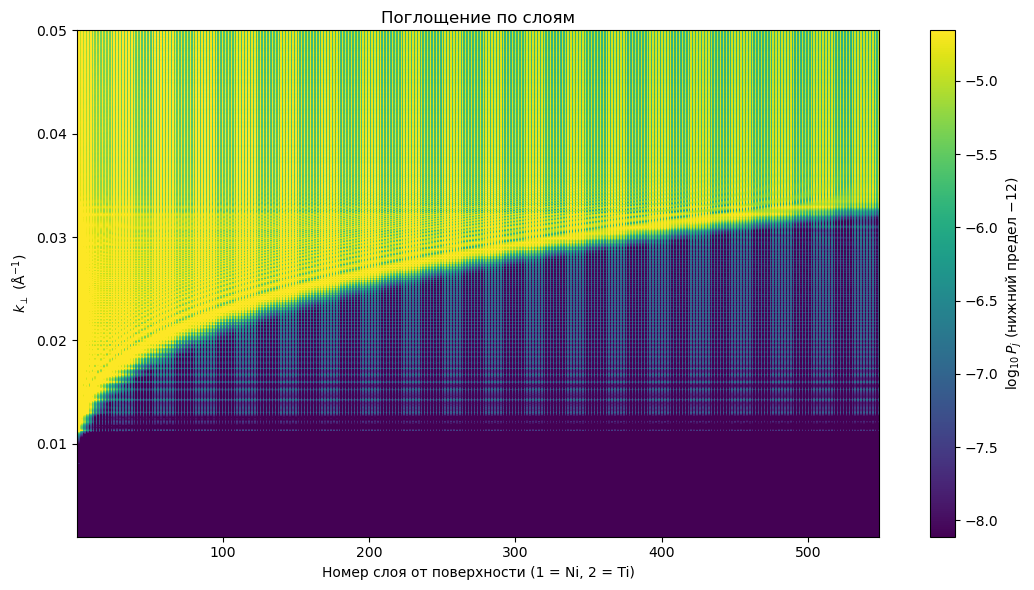

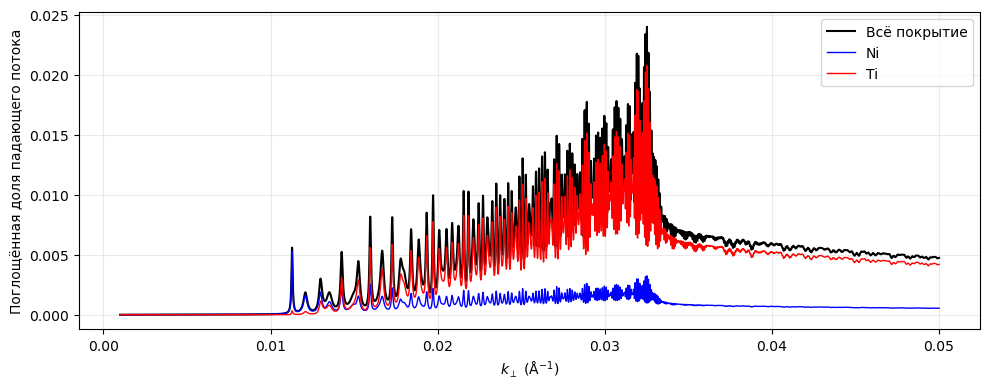

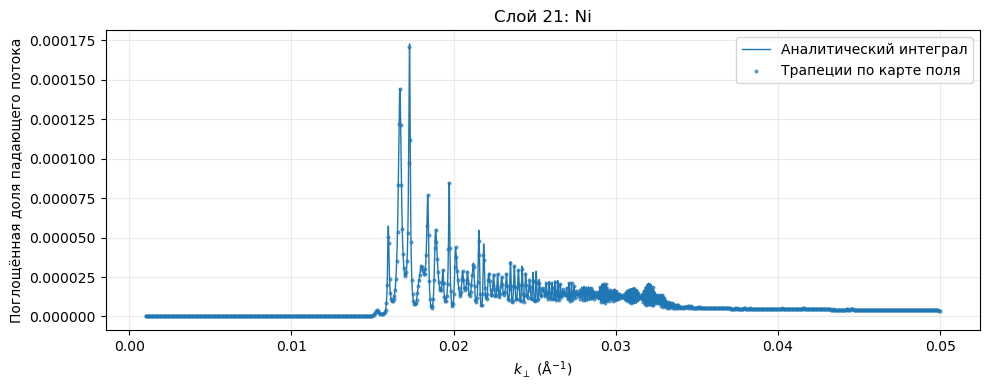

In [70]:

# Основной расчёт: все 5000 значений падающего k_perp, все 548 конечных слоёв.
im_sld_abs = layers_test[1:-1, 2]
integrals_layers = integrate_layers_analytic(A_test, B_test, k_test, layers_test)
absorption = compute_absorption(integrals_layers, im_sld_abs, q_test)
# absorption.shape == (548, 5000): слои × падающие волновые векторы.
# Не переопределяем shape вручную: это не транспонирование!
absorption_total = absorption.sum(axis=0)
absorption_Ni = absorption[0::2].sum(axis=0)
absorption_Ti = absorption[1::2].sum(axis=0)



# Независимая проверка по токам, а не по остатку 1-R-T.
layer_current_losses = to_numpy(diagnostics["L_layers"]).T
layer_error = np.max(np.abs(absorption - layer_current_losses))
absorption_balance = to_numpy(R + T) + absorption_total - 1
balance_error = np.max(np.abs(absorption_balance))
print("absorption.shape (слои, k):", absorption.shape)
print(f"Поглощение покрытия: {absorption_total.min():.8g} ... {absorption_total.max():.8g}")
print(f"max |послойное поглощение − потери по токам| = {layer_error:.3e}")
print(f"max |R+T+sum(P_j)-1| = {balance_error:.3e}")
assert layer_error < 1e-8
assert balance_error < 1e-8
assert np.allclose(absorption_Ni + absorption_Ti, absorption_total, atol=1e-13, rtol=1e-12)

# Сравнение с адаптированным старым методом на сетке карты psi2_test.
integrals_grid = integrate_layers(psi2_test, z_test, interfaces)
absorption_grid = compute_absorption(integrals_grid, im_sld_abs, q_plot)
indices_np = to_numpy(plot_indices).astype(int)
absorption_exact_on_grid = absorption[:, indices_np]
grid_difference = np.max(np.abs(absorption_grid - absorption_exact_on_grid))
grid_balance_error = np.max(np.abs(to_numpy(R[plot_indices] + T[plot_indices])
                                   + absorption_grid.sum(axis=0) - 1))
print(f"Трапеции, сетка {len(z_test)} точек z: max |P_grid−P_exact| = {grid_difference:.3e}")
print(f"Трапеции: max |R+T+sum(P_grid)-1| = {grid_balance_error:.3e}")

plot_absorption(absorption, q_test)

fig, ax = plt.subplots(figsize=(10, 4))
k_np = to_numpy(q_test)
ax.plot(k_np, absorption_total, label="Всё покрытие", color="black")
ax.plot(k_np, absorption_Ni, label="Ni", lw=1, color="blue")
ax.plot(k_np, absorption_Ti, label="Ti", lw=1, color="red")
ax.set(xlabel=r"$k_\perp$ (Å$^{-1}$)", ylabel="Поглощённая доля падающего потока")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Аналог старого среза bez_log[:, 100]: индекс 100 соответствует физическому слою 101.
LAYER_NUMBER = 21  # 1..548; нечётные Ni, чётные Ti
if not 1 <= LAYER_NUMBER <= absorption.shape[0]:
    raise ValueError("Номер слоя вне диапазона.")
layer_index = LAYER_NUMBER - 1
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_np, absorption[layer_index], lw=1, label="Аналитический интеграл")
ax.scatter(to_numpy(q_plot), absorption_grid[layer_index], s=4, alpha=0.6,
           label="Трапеции по карте поля")
ax.set(xlabel=r"$k_\perp$ (Å$^{-1}$)", ylabel="Поглощённая доля падающего потока",
       title=f"Слой {LAYER_NUMBER}: {'Ni' if LAYER_NUMBER % 2 else 'Ti'}")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


Формула аналитического интеграла получена интегрированием используемого поля
$\psi(x)=A e^{ikx}+B e^{ik(d-x)}$. При $k=a+ib$:

$$I=(|A|^2+|B|^2)\frac{1-e^{-2bd}}{2b}
+2\operatorname{Re}(AB^*)e^{-bd}\,d\,\mathrm{sinc}(ad/\pi).$$

При $b=0$ дробь равна $d$; здесь используется нормированная sinc.
Таким образом, основной результат не зависит от шага `z_test`.
Умножать только на $1/k_\perp$ недостаточно: сам интеграл поля зависит от $k_\perp$.
Поэтому произвольная кривая `1/q` удалена из графика безразмерного поглощения.

Документация: [NumPy trapezoid](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html),
[torch.expm1](https://docs.pytorch.org/docs/2.14/generated/torch.expm1.html),
[torch.sinc](https://docs.pytorch.org/docs/2.14/generated/torch.sinc.html),
[Matplotlib pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html).


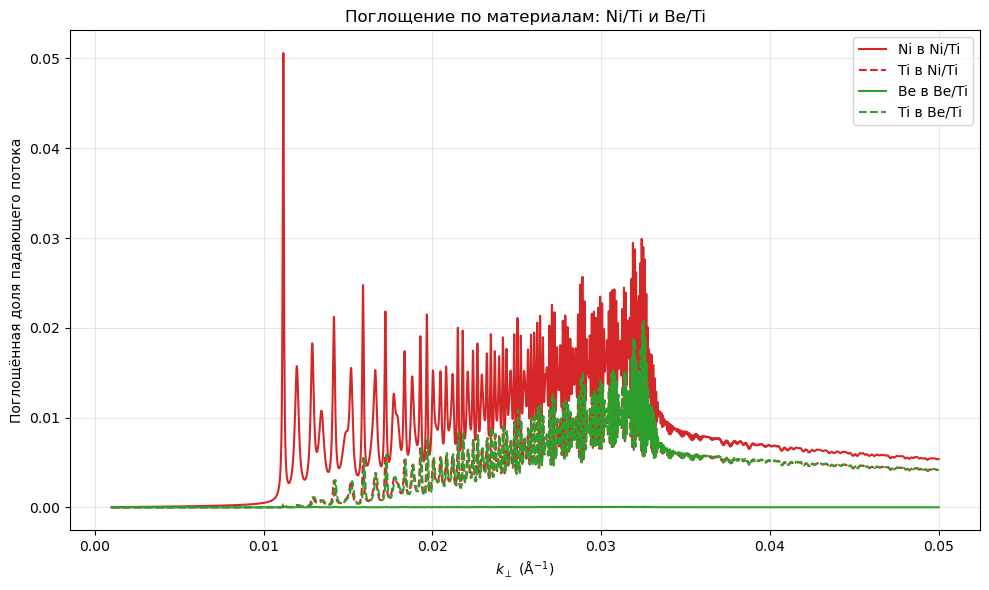

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))

k_np = q_test.detach().cpu().numpy()
#поглощение для Be взяли из документации https://www.ncnr.nist.gov/resources/activation/ (оно очень маленькое)
for material, sld_re, sld_im, color in [
    ("Ni", 9.408, 0.001, "tab:red"),
    ("Be", 9.620, 2.6e-6, "tab:green"),
]:
    # Копия структуры: сохраняем толщины и параметры подложки
    layers = layers_test.clone()

    # Нечётные физические слои: Ni или Be
    layers[1:-1:2, 1] = sld_re
    layers[1:-1:2, 2] = sld_im

    # Чётные физические слои: Ti
    layers[2:-1:2, 1] = -1.925
    layers[2:-1:2, 2] = 0.001

    # Поле пересчитывается для каждой структуры
    _, k, A, B, _, _ = stable_multilayer_fields(
        q_test, layers, device=device
    )

    integrals = integrate_layers_analytic(A, B, k, layers)

    absorption = compute_absorption(
        integrals, layers[1:-1, 2], q_test
    )

    # Суммы только по слоям соответствующего материала
    absorption_material = absorption[0::2].sum(axis=0)
    absorption_ti = absorption[1::2].sum(axis=0)

    ax.plot(
        k_np, absorption_material,
        color=color, label=f"{material} в {material}/Ti"
    )
    ax.plot(
        k_np, absorption_ti,
        color=color, linestyle="--", label=f"Ti в {material}/Ti"
    )

ax.set_xlabel(r"$k_\perp$ (Å$^{-1}$)")
ax.set_ylabel("Поглощённая доля падающего потока")
ax.set_title("Поглощение по материалам: Ni/Ti и Be/Ti")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

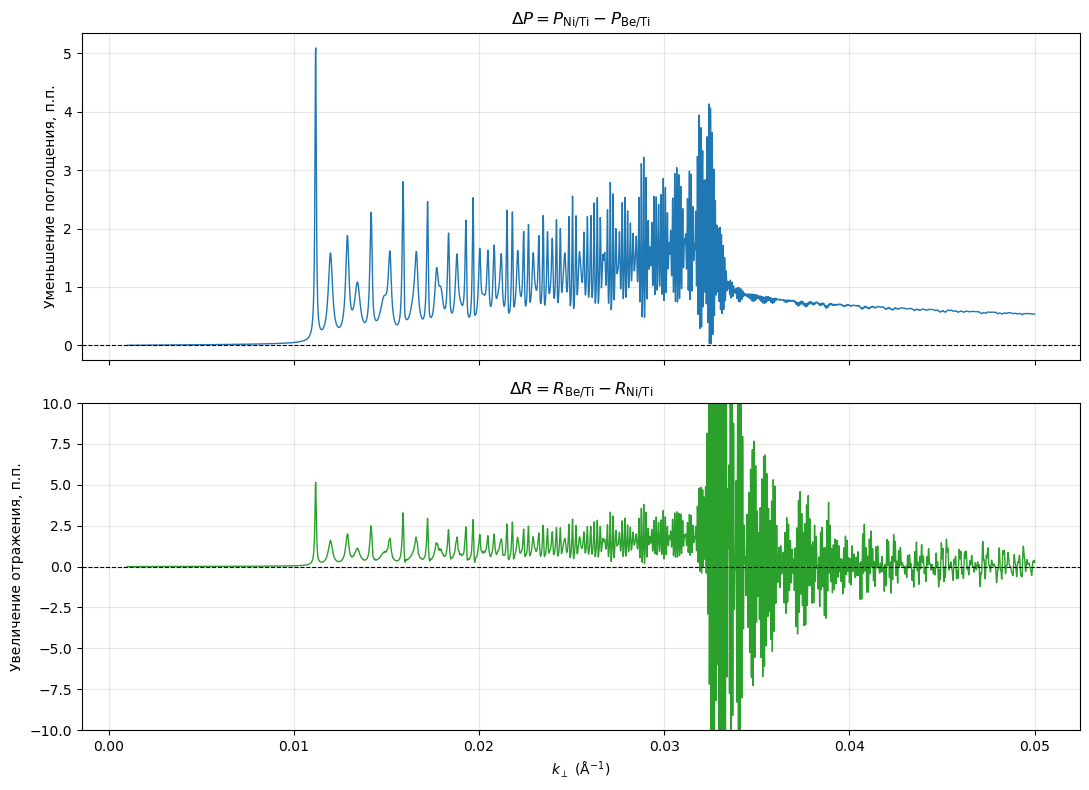

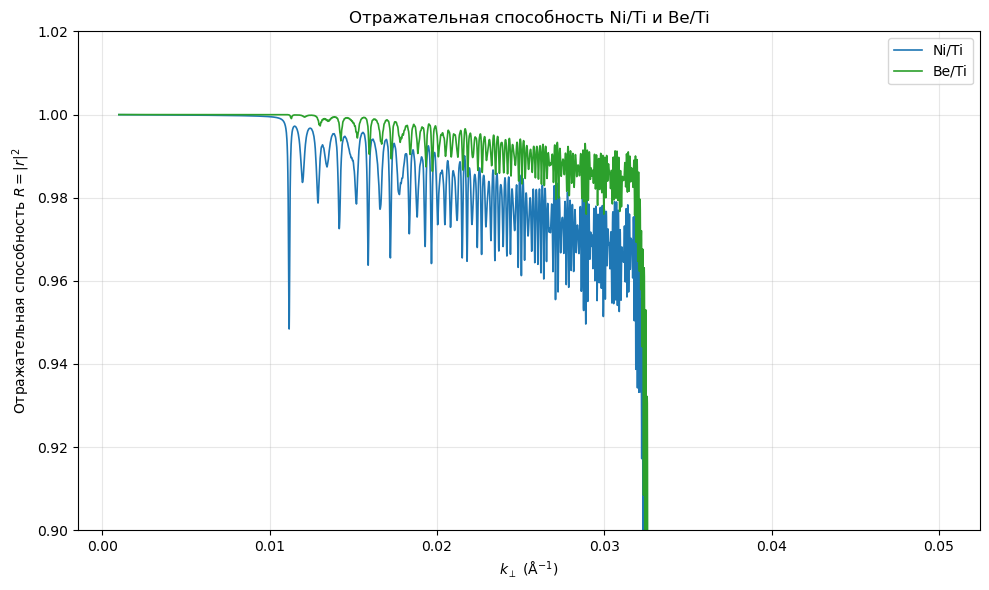

In [72]:
# Параметры SLD в единицах 10^-6 Å^-2
materials = {
    "Ni/Ti": (9.408, 0.001),
    "Be/Ti": (9.620, 2.6e-6),
}

results = {}

for structure, (sld_re, sld_im) in materials.items():
    # Сохраняем исходную структуру, толщины и параметры подложки
    layers = layers_test.clone()

    # Ni или Be
    layers[1:-1:2, 1] = sld_re
    layers[1:-1:2, 2] = sld_im

    # Ti
    layers[2:-1:2, 1] = -1.925
    layers[2:-1:2, 2] = 0.001

    # Расчёт поля
    r, k, A, B, _, _ = stable_multilayer_fields(
        q_test, layers, device=device
    )

    # Отражение и прохождение по потоку
    reflectivity = torch.abs(r) ** 2
    transmission = (
        k[:, -1].real / k[:, 0].real
        * torch.abs(A[:, -1]) ** 2
    )

    # Поглощение во всех конечных слоях, включая Ti
    integrals = integrate_layers_analytic(A, B, k, layers)
    absorption_layers = compute_absorption(
        integrals, layers[1:-1, 2], q_test
    )

    results[structure] = {
        "R": reflectivity.detach().cpu().numpy(),
        "T": transmission.detach().cpu().numpy(),
        "P": absorption_layers.sum(axis=0),
    }

# Уменьшение поглощения и увеличение отражения
delta_P = results["Ni/Ti"]["P"] - results["Be/Ti"]["P"]
delta_R = results["Be/Ti"]["R"] - results["Ni/Ti"]["R"]

# Перевод в процентные пункты от падающего потока
delta_P_pp = 100 * delta_P
delta_R_pp = 100 * delta_R

k_np = q_test.detach().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(k_np, delta_P_pp, color="tab:blue", linewidth=1)
axes[0].set_ylabel("Уменьшение поглощения, п.п.")
axes[0].set_title(r"$\Delta P = P_{\mathrm{Ni/Ti}} - P_{\mathrm{Be/Ti}}$")

axes[1].plot(k_np, delta_R_pp, color="tab:green", linewidth=1)
axes[1].set_ylabel("Увеличение отражения, п.п.")
axes[1].set_ylim(-10,10)
axes[1].set_title(r"$\Delta R = R_{\mathrm{Be/Ti}} - R_{\mathrm{Ni/Ti}}$")
axes[1].set_xlabel(r"$k_\perp$ (Å$^{-1}$)")

for ax in axes:
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))

plt.plot(
    k_np, results["Ni/Ti"]["R"],
    label="Ni/Ti", color="tab:blue", linewidth=1.2
)
plt.plot(
    k_np, results["Be/Ti"]["R"],
    label="Be/Ti", color="tab:green", linewidth=1.2
)

plt.xlabel(r"$k_\perp$ (Å$^{-1}$)")
plt.ylabel(r"Отражательная способность $R = |r|^2$")
plt.title("Отражательная способность Ni/Ti и Be/Ti")
plt.ylim(0.9, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()